**BO1: Aide les entreprises à anticiper les métiers à recruter et adapter leurs plans RH et formation**
Classifier des métiers selon trajectoire 2024→2030(croissance / stable / déclin).

knn - tree, XGBoost, Logistic Regression

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder,PolynomialFeatures,StandardScaler
from scipy.stats import randint, uniform
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold,KFold, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                           precision_score, recall_score, f1_score, precision_recall_fscore_support,
                           balanced_accuracy_score, make_scorer,roc_curve, roc_auc_score)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

**Load the prepared dataset**

In [48]:
df =  pd.read_csv(r"C:\Users\meria\Desktop\ING\mlProject\prepared_data.csv")
print(f"Dataset shape: {df.shape}")


if "Job_Status" not in df.columns:
    raise ValueError("Colonne Job_Status manquante")
print("Target trouvée: Job_Status")

Dataset shape: (10000, 15)
Target trouvée: Job_Status


In [49]:
target = "Job_Status"

LEAKAGE_FEATURES = ['Job_Status','Job_Growth_Rate_%','Growth_Category']
X = df.select_dtypes(include=[np.number]).drop(columns=LEAKAGE_FEATURES, errors="ignore")

y = df["Job_Status"].map({"decreasing": 0, "increasing": 1}).astype(int)
print("\nTarget distribution:")
print(y.value_counts(normalize=True))
class_names = ["decreasing", "increasing"]


Target distribution:
Job_Status
0    0.5019
1    0.4981
Name: proportion, dtype: float64


**Split the data**

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nData Split:")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Training target distribution: {dict(zip(class_names, np.bincount(y_train)))}")


Data Split:
Training set: (8000, 11)
Test set: (2000, 11)
Training target distribution: {'decreasing': np.int64(4015), 'increasing': np.int64(3985)}


In [51]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **KNN**

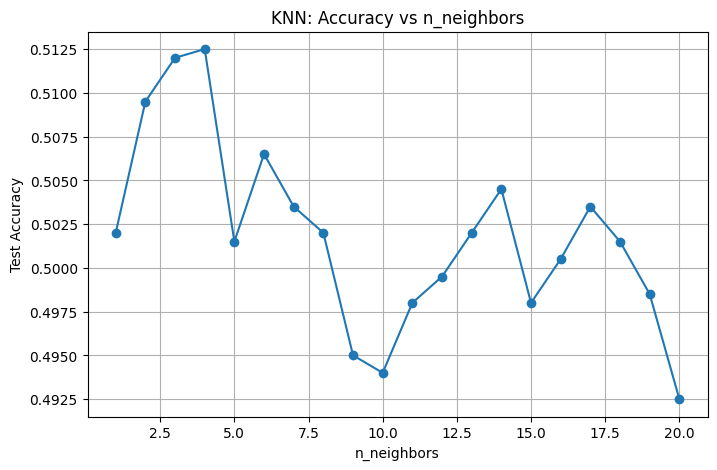

In [105]:
import matplotlib.pyplot as plt

neighbors_range = range(1, 21)  # test k = 1 à 20
test_scores = []

for k in neighbors_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    test_scores.append(knn.score(X_test_scaled, y_test))

plt.figure(figsize=(8,5))
plt.plot(neighbors_range, test_scores, marker='o')
plt.xlabel("n_neighbors")
plt.ylabel("Test Accuracy")
plt.title("KNN: Accuracy vs n_neighbors")
plt.grid(True)
plt.show()


In [106]:
knn_baseline = KNeighborsClassifier(n_neighbors=3)
knn_baseline.fit(X_train_scaled, y_train)
y_pred_knn = knn_baseline.predict(X_test_scaled)
acc_knn= accuracy_score(y_test, y_pred_knn)

print(f" KNN Baseline - Accuracy: {acc_knn:.3f}")
print("\nRapport de classification KNN basique :")
print(classification_report(y_test, y_pred_knn))


 KNN Baseline - Accuracy: 0.512

Rapport de classification KNN basique :
              precision    recall  f1-score   support

           0       0.51      0.52      0.52      1004
           1       0.51      0.51      0.51       996

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000



**Optimisation KNN avec GridSearchCV**

In [107]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean']
}
knn_grid = GridSearchCV(
    KNeighborsClassifier(), 
    param_grid_knn, 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)
knn_grid.fit(X_train, y_train)   
best_knn = knn_grid.best_estimator_
y_pred_knn_opt = best_knn.predict(X_test)
acc_knn_opt = accuracy_score(y_test, y_pred_knn_opt)

**evaluation**

In [108]:
print(f" KNN OPTIMISÉ - Performances:")
print(f"   • Accuracy: {acc_knn_opt:.4f}")
print(f"   • Meilleurs paramètres: {knn_grid.best_params_}")
print("\nRapport de classification KNN optimisé :")
print(classification_report(y_test, y_pred_knn_opt, target_names=class_names))


 KNN OPTIMISÉ - Performances:
   • Accuracy: 0.5125
   • Meilleurs paramètres: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}

Rapport de classification KNN optimisé :
              precision    recall  f1-score   support

  decreasing       0.51      0.52      0.52      1004
  increasing       0.51      0.50      0.51       996

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000



**visualisation**

**Matrice de confusion**

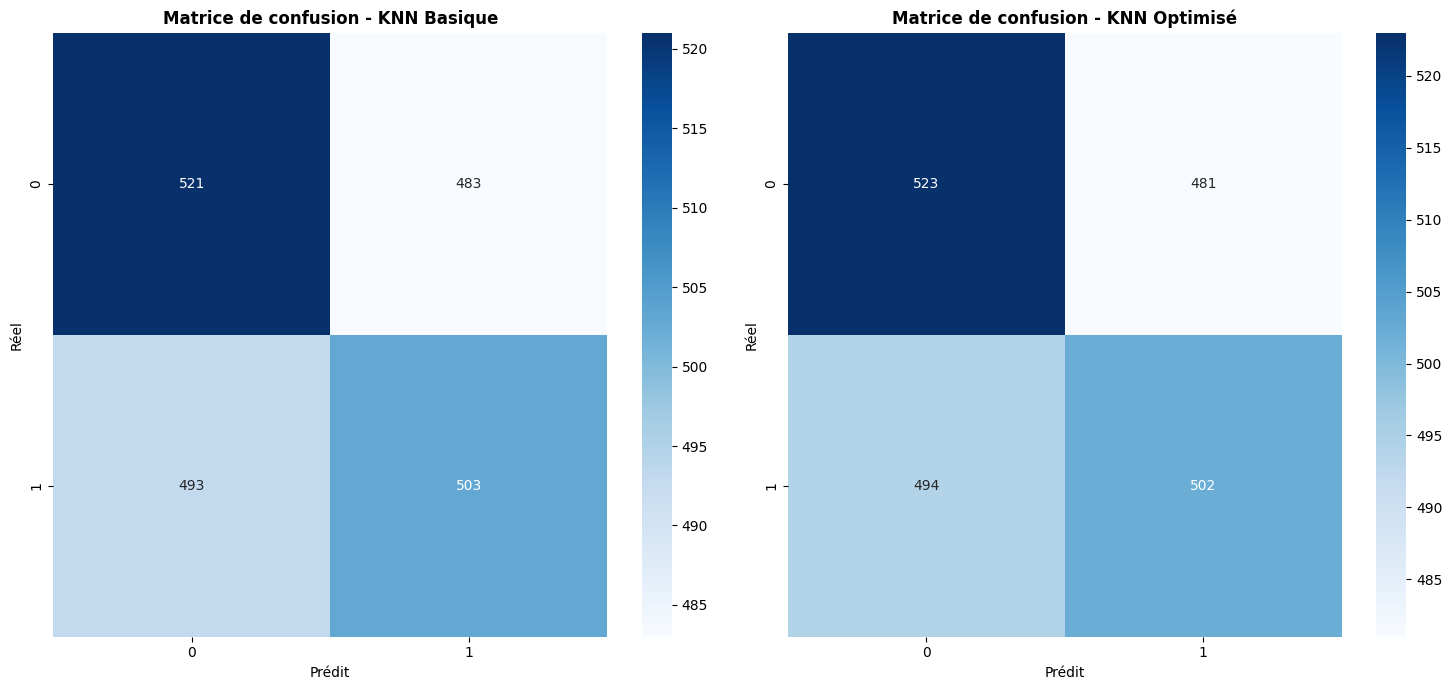

In [109]:
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
cm_basic = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_basic, annot=True, fmt='d', cmap='Blues')  
plt.title("Matrice de confusion - KNN Basique", fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')

plt.subplot(1, 2, 2)
cm_opt = confusion_matrix(y_test, y_pred_knn_opt)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues') 
plt.title("Matrice de confusion - KNN Optimisé", fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

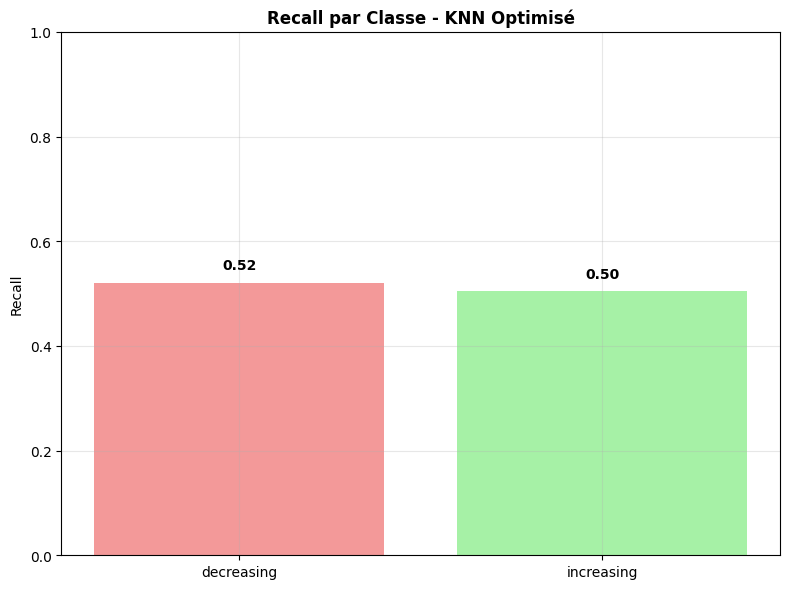

In [110]:
plt.figure(figsize=(8, 6))
recall_knn = recall_score(y_test, y_pred_knn_opt, average=None)
x_pos = np.arange(len(class_names))
plt.bar(x_pos, recall_knn, color=['lightcoral', 'lightgreen'], alpha=0.8)  
plt.title('Recall par Classe - KNN Optimisé', fontweight='bold')
plt.ylabel('Recall')
plt.xticks(x_pos, class_names)
plt.ylim(0, 1)
for i, v in enumerate(recall_knn):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

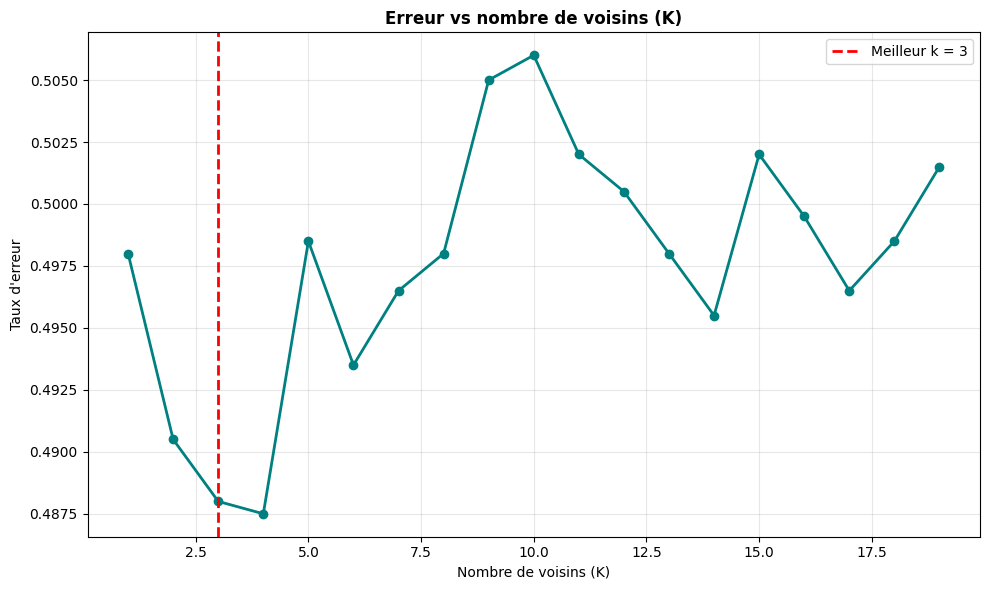

In [111]:
plt.figure(figsize=(10, 6))
errors = []
neighbors_range = range(1, 20)
for k in neighbors_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred_k = model.predict(X_test_scaled)
    errors.append(1 - accuracy_score(y_test, pred_k))

plt.plot(neighbors_range, errors, marker='o', linestyle='-', color='teal', linewidth=2, markersize=6)
plt.axvline(x=knn_grid.best_params_['n_neighbors'], color='red', linestyle='--', 
            label=f'Meilleur k = {knn_grid.best_params_["n_neighbors"]}', linewidth=2)
plt.title("Erreur vs nombre de voisins (K)", fontweight='bold')
plt.xlabel("Nombre de voisins (K)")
plt.ylabel("Taux d'erreur")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# **Modèle Arbre de Décision** 


In [122]:
tree_baseline = DecisionTreeClassifier(random_state=42)
tree_baseline.fit(X_train, y_train)
y_pred_tree= tree_baseline.predict(X_test)
acc_tree= accuracy_score(y_test, y_pred_tree)

In [123]:

print(f"Arbre Baseline (défaut) - Accuracy: {acc_tree:.3f}")
print(f"   • Profondeur: {tree_baseline.get_depth()}")
print(f"   • Feuilles: {tree_baseline.get_n_leaves()}")

Arbre Baseline (défaut) - Accuracy: 0.512
   • Profondeur: 33
   • Feuilles: 1998


**Optimisation Arbre avec GridSearchCV**

In [ ]:
param_grid_tree = {
    'max_depth': [5, 10, 15, 20, None],       # None = baseline
    'min_samples_split': [2, 10, 20, 50],     # 2 = baseline
    'min_samples_leaf': [1, 5, 10, 20],       # 1 = baseline
    'criterion': ['gini', 'entropy'],         # 'gini' = baseline
    'max_features': [None, 'sqrt', 'log2']    # None = baseline
}

grid_search_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_tree,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)

grid_search_tree.fit(X_train, y_train)

best_params = grid_search_tree.best_params_
best_score = grid_search_tree.best_score_

In [126]:
print(f"\nMeilleurs paramètres trouvés : {best_params}")
print(f"Balanced Accuracy CV : {best_score:.3f}")

best_tree = grid_search_tree.best_estimator_
y_pred_best = best_tree.predict(X_test)
acc_best = accuracy_score(y_test, y_pred_best)
print(f"\n Accuracy test avec meilleur arbre : {acc_best:.3f}")
print(f"   • Profondeur: {best_tree.get_depth()}")
print(f"   • Feuilles: {best_tree.get_n_leaves()}")


Meilleurs paramètres trouvés : {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'min_samples_split': 2}
Balanced Accuracy CV : 0.516

 Accuracy test avec meilleur arbre : 0.471
   • Profondeur: 10
   • Feuilles: 136


**Validation Croisée Arbre**


In [127]:
cv_scores_tree = cross_val_score(best_tree, X_train, y_train, cv=5, scoring='accuracy')
print(f"\nVALIDATION CROISÉE ARBRE:")
print(f"  • Scores CV: {[f'{s:.4f}' for s in cv_scores_tree]}")
print(f"  • Moyenne:   {cv_scores_tree.mean():.4f} (± {cv_scores_tree.std():.4f})")


VALIDATION CROISÉE ARBRE:
  • Scores CV: ['0.5175', '0.5012', '0.5181', '0.4906', '0.5175']
  • Moyenne:   0.5090 (± 0.0112)


In [128]:
importances_tree = pd.Series(best_tree.feature_importances_, index=X.columns)
importances_tree = importances_tree.sort_values(ascending=False)
top_features_tree = importances_tree[importances_tree > 0].head(15)

print(f"\nTOP {len(top_features_tree)} FEATURES IMPORTANTES - ARBRE:")
for i, (feature, importance) in enumerate(top_features_tree.items(), 1):
    print(f"   {i:2d}. {feature:35} {importance:7.4f} ")


TOP 11 FEATURES IMPORTANTES - ARBRE:
    1. Automation_Risk_%                    0.1738 
    2. Gender_Diversity_%                   0.1678 
    3. Vulnerability_Index                  0.1262 
    4. Remote_Work_Ratio_%                  0.1259 
    5. Job_Value_Index                      0.1098 
    6. Median_Salary_USD                    0.0792 
    7. Education_Level                      0.0644 
    8. Experience_Required_Years            0.0558 
    9. Location                             0.0347 
   10. Industry                             0.0333 
   11. AI_Impact_Level                      0.0290 


**Visualisations Arbre**


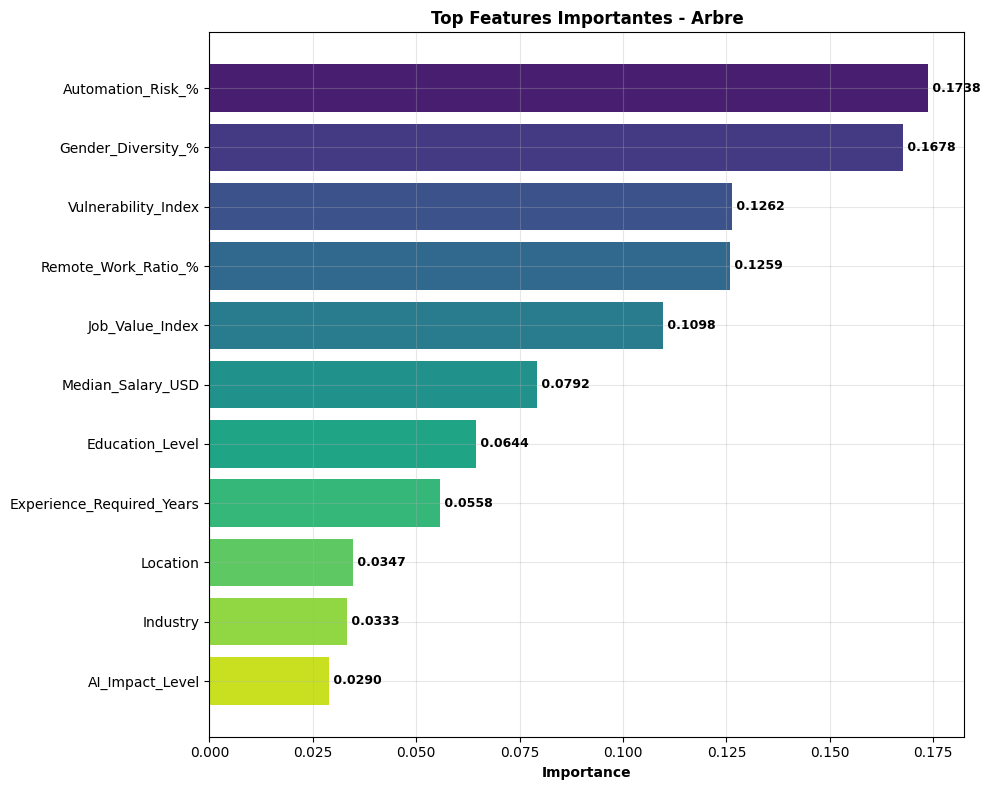

In [129]:
plt.figure(figsize=(10, 8))
colors = sns.color_palette("viridis", len(top_features_tree))
bars = plt.barh(range(len(top_features_tree)), top_features_tree.values, color=colors)
plt.yticks(range(len(top_features_tree)), top_features_tree.index)
plt.xlabel('Importance', fontweight='bold')
plt.title('Top Features Importantes - Arbre', fontweight='bold')
plt.gca().invert_yaxis()
for i, (bar, val) in enumerate(zip(bars, top_features_tree.values)):
    plt.text(val, i, f' {val:.4f}', va='center', fontsize=9, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

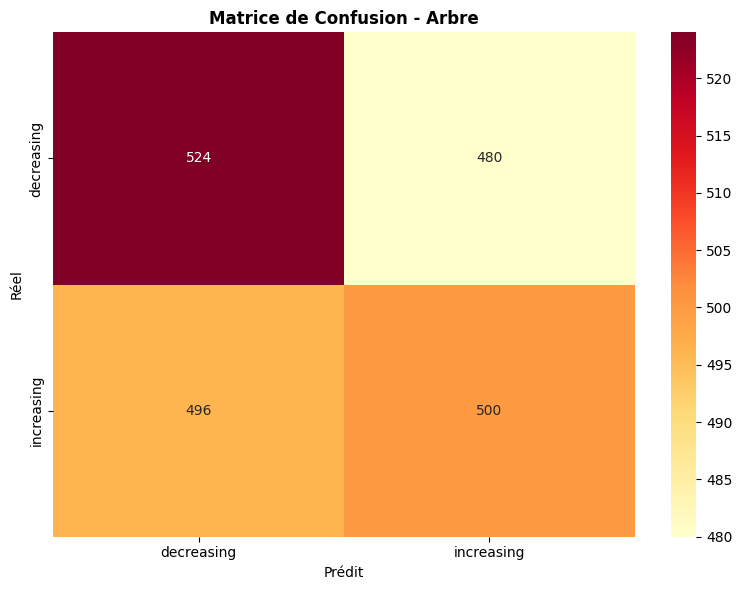

In [130]:
# Matrice de confusion Arbre
plt.figure(figsize=(8, 6))
cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de Confusion - Arbre', fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

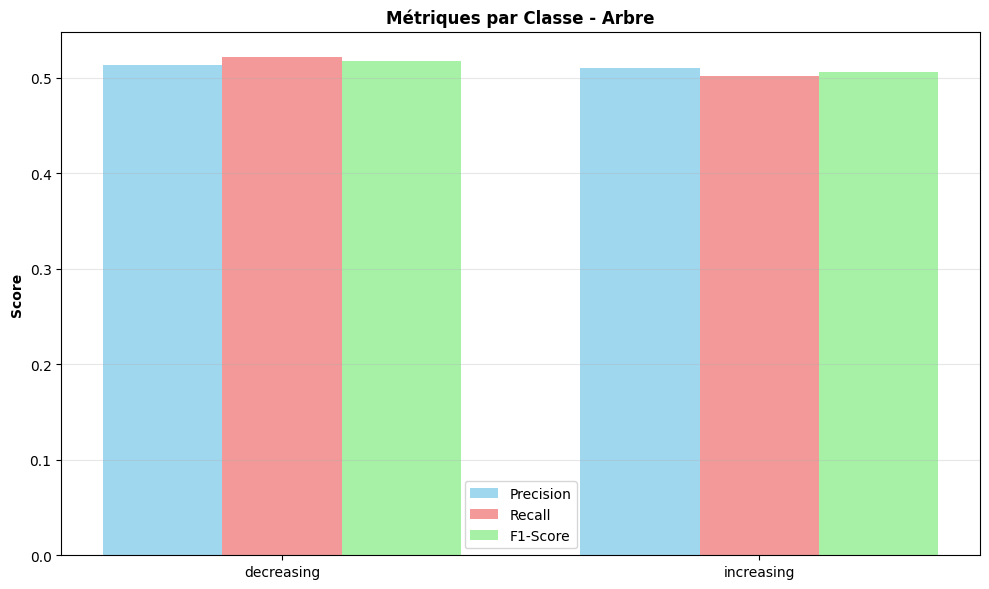

In [131]:
plt.figure(figsize=(10, 6))
precision_tree, recall_tree, f1_tree, _ = precision_recall_fscore_support(y_test, y_pred_tree, average=None)
x_pos = np.arange(len(class_names))
width = 0.25
plt.bar(x_pos - width, precision_tree, width, label='Precision', alpha=0.8, color='skyblue')
plt.bar(x_pos, recall_tree, width, label='Recall', alpha=0.8, color='lightcoral')
plt.bar(x_pos + width, f1_tree, width, label='F1-Score', alpha=0.8, color='lightgreen')
plt.ylabel('Score', fontweight='bold')
plt.title('Métriques par Classe - Arbre', fontweight='bold')
plt.xticks(x_pos, class_names)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


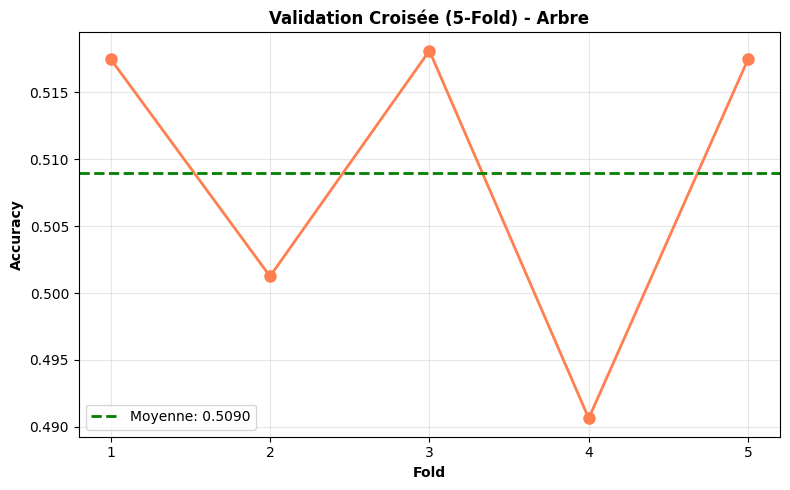

In [132]:
# Cross-validation plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), cv_scores_tree, 'o-', linewidth=2, markersize=8, color='coral')
plt.axhline(cv_scores_tree.mean(), color='green', linestyle='--', 
           label=f'Moyenne: {cv_scores_tree.mean():.4f}', linewidth=2)
plt.xlabel('Fold', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.title('Validation Croisée (5-Fold) - Arbre', fontweight='bold')
plt.xticks(range(1, 6))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

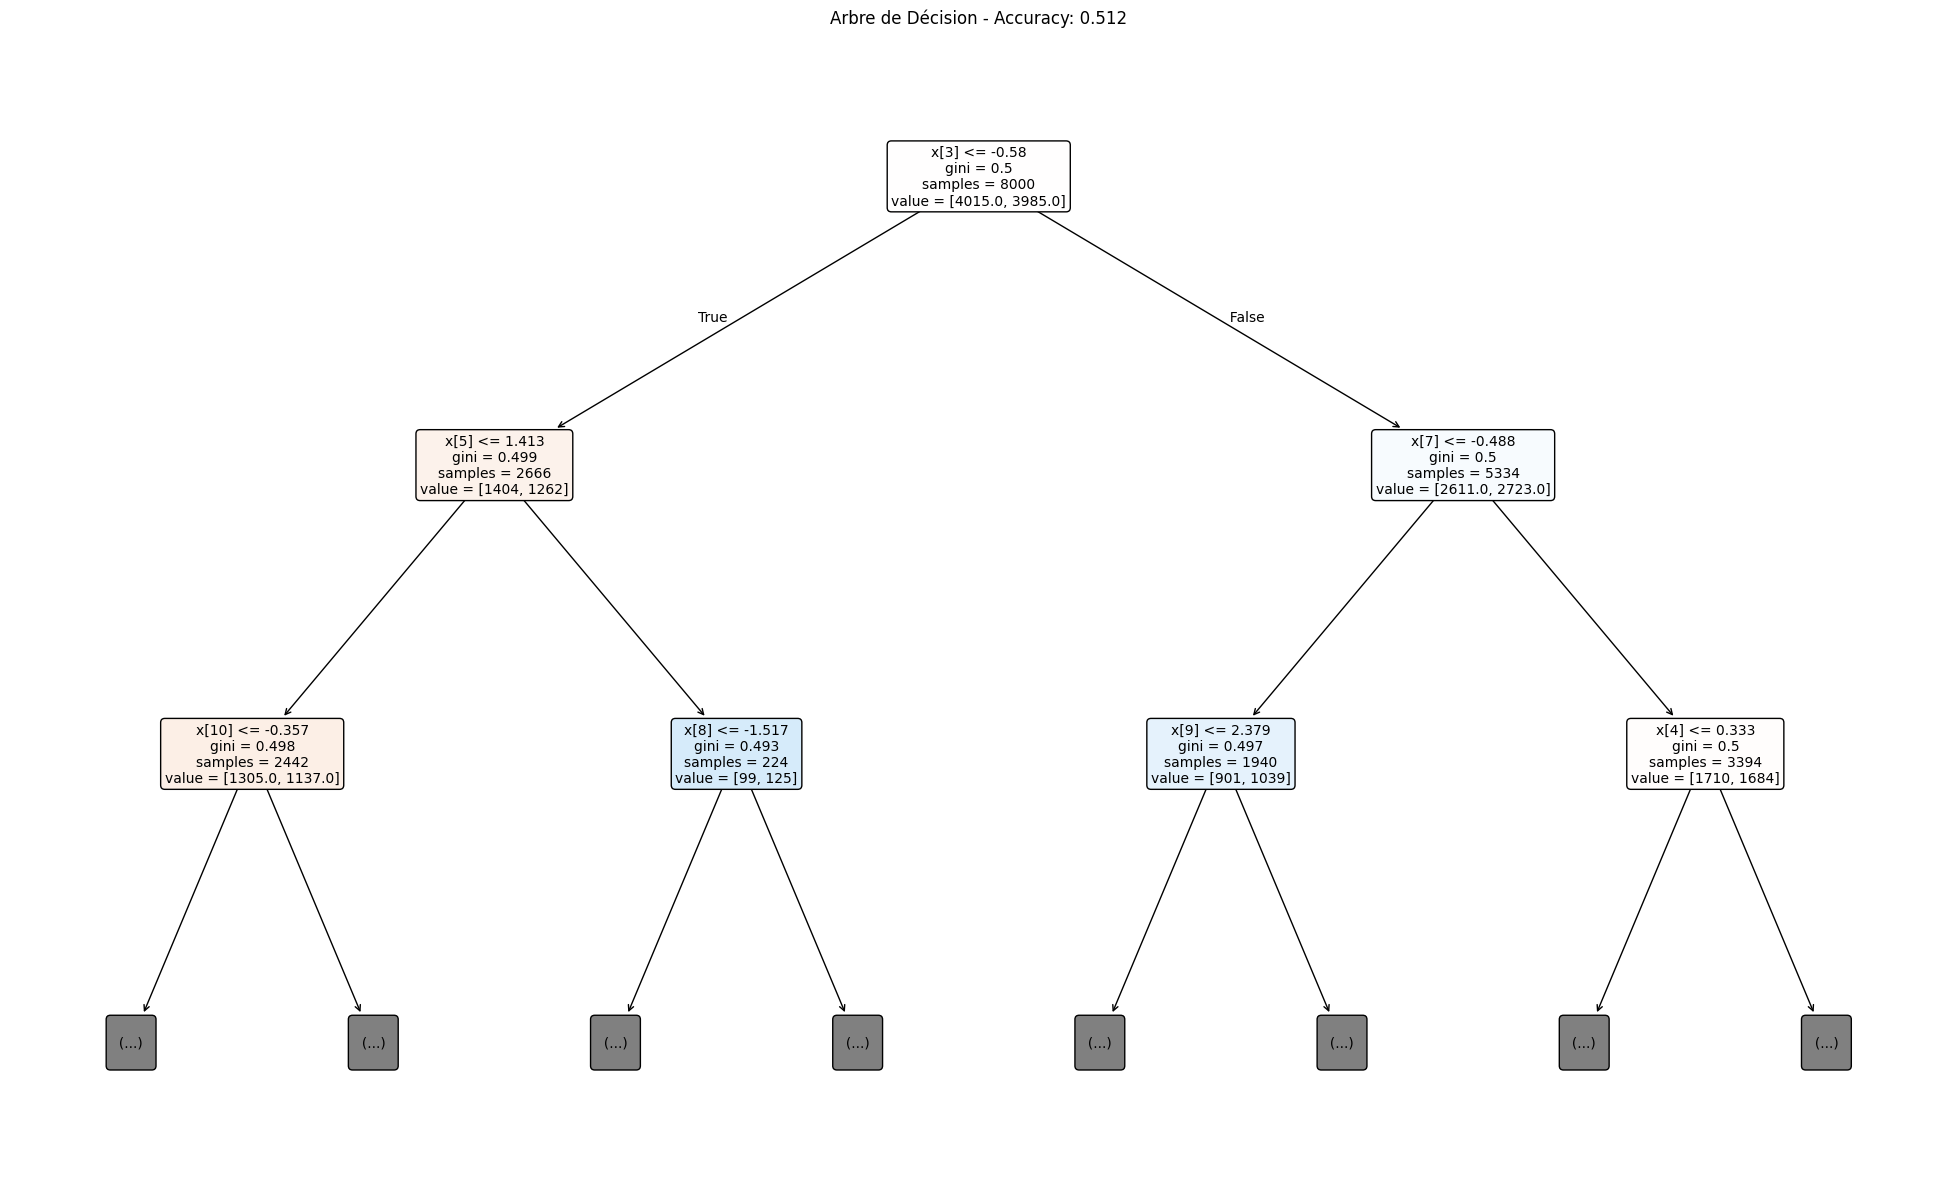

In [133]:
fig = plt.figure(figsize=(25, 15))
plot_tree(best_tree,
         filled=True,
         rounded=True,
         fontsize=10,
         max_depth=2)  
plt.title(f'Arbre de Décision - Accuracy: {acc_tree:.3f}')
plt.show()

# **Régression Logistique**


In [134]:
lr_baseline = LogisticRegression(random_state=42, max_iter=1000)
lr_baseline.fit(X_train_scaled, y_train)
y_pred_lr = lr_baseline.predict(X_test_scaled)
acc_lr_baseline = accuracy_score(y_test, y_pred_lr)

print(f"Regression - Accuracy: {acc_lr_baseline:.3f}")

Regression - Accuracy: 0.514


In [135]:
# Optimisation Regression
param_grid_lr = {
     'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'], 
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': ['balanced', None]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=2000),
    param_grid_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)
print("Recherche des meilleurs paramètres pour la regression...")
lr_grid.fit(X_train, y_train)

best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)
bal_acc_lr = balanced_accuracy_score(y_test, y_pred_lr)


Recherche des meilleurs paramètres pour la regression...
Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [136]:
print(f"RÉGRESSION OPTIMISÉE - Performances:")
print(f"  • Accuracy: {acc_lr:.4f}")
print(f"  • Balanced Accuracy: {bal_acc_lr:.4f}")
print(f"  • Meilleurs paramètres: {lr_grid.best_params_}")
print("\nRapport de classification Regression optimisée :")
print(classification_report(y_test, y_pred_lr, target_names=class_names))

RÉGRESSION OPTIMISÉE - Performances:
  • Accuracy: 0.5035
  • Balanced Accuracy: 0.5032
  • Meilleurs paramètres: {'C': 0.001, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}

Rapport de classification Regression optimisée :
              precision    recall  f1-score   support

  decreasing       0.50      0.57      0.53      1004
  increasing       0.50      0.44      0.47       996

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.50      0.50      0.50      2000



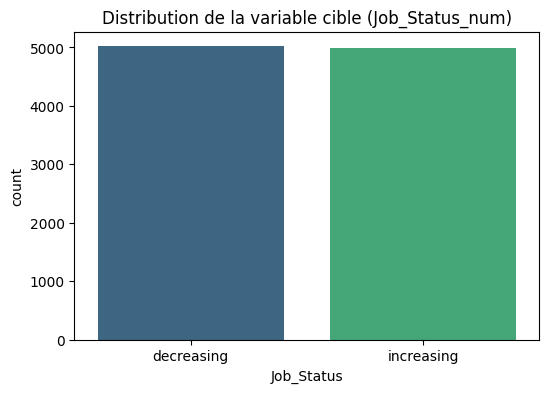

In [137]:
plt.figure(figsize=(6,4))
sns.countplot(x=y, palette="viridis")
plt.title("Distribution de la variable cible (Job_Status_num)")
plt.xticks([0,1], ["decreasing", "increasing"])
plt.show()

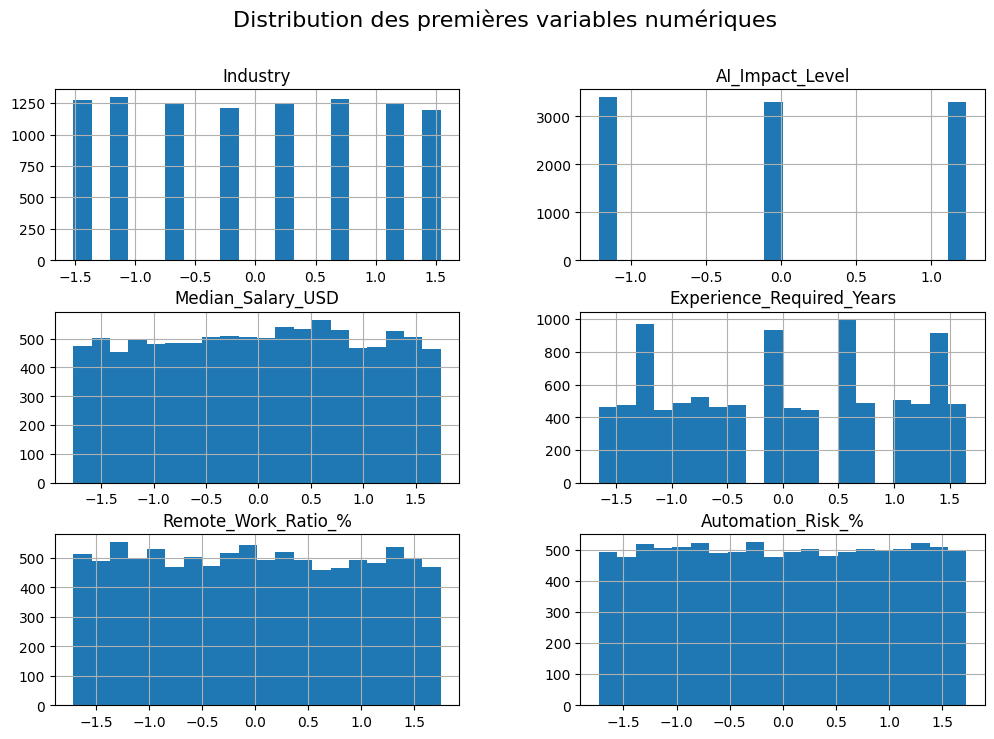

In [138]:
numeric_cols = X.columns[:6]  # les 6 premières pour éviter un énorme plot
df[numeric_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Distribution des premières variables numériques", fontsize=16)
plt.show()

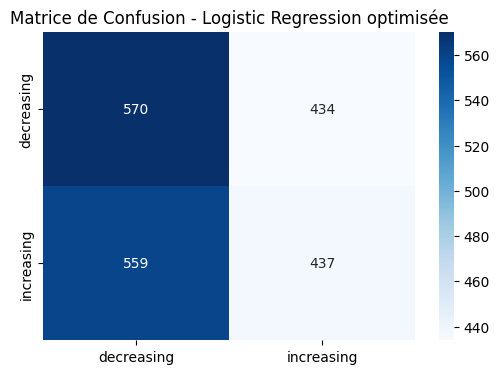

In [139]:

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matrice de Confusion - Logistic Regression optimisée")
plt.show()


ROC Curve 

**Polynomial**

In [140]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
print("Dimensions avant:", X_train_scaled.shape)
print("Dimensions après:", X_train_poly.shape)


Dimensions avant: (8000, 11)
Dimensions après: (8000, 77)


In [141]:
lr_poly = LogisticRegression(max_iter=5000, solver="saga")
lr_poly.fit(X_train_poly, y_train)

y_pred_poly = lr_poly.predict(X_test_poly)

acc_poly = accuracy_score(y_test, y_pred_poly)
bal_acc_poly = balanced_accuracy_score(y_test, y_pred_poly)

print(f" Régression polynomiale - Performances :")
print(f"  • Accuracy: {acc_poly:.4f}")
print(f"  • Balanced Accuracy: {bal_acc_poly:.4f}")

print("\n Rapport de classification (Régression polynomiale) :")
print(classification_report(y_test, y_pred_poly, target_names=class_names))


 Régression polynomiale - Performances :
  • Accuracy: 0.5035
  • Balanced Accuracy: 0.5035

 Rapport de classification (Régression polynomiale) :
              precision    recall  f1-score   support

  decreasing       0.51      0.51      0.51      1004
  increasing       0.50      0.50      0.50       996

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.50      0.50      0.50      2000



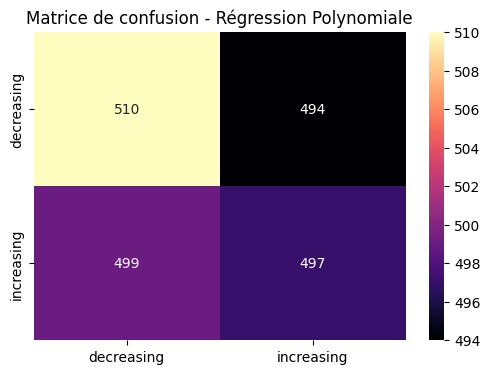

In [142]:
cm_poly = confusion_matrix(y_test, y_pred_poly)

plt.figure(figsize=(6,4))
sns.heatmap(cm_poly, annot=True, fmt="d", cmap="magma",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matrice de confusion - Régression Polynomiale")
plt.show()


# **XGboost**

In [157]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# ===========================
# 1️⃣ Baseline XGBoost
# ===========================
xgb_baseline = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

# Entraînement
xgb_baseline.fit(X_train, y_train)

# Prédiction
y_pred_baseline = xgb_baseline.predict(X_test)

# Scores
acc_baseline = accuracy_score(y_test, y_pred_baseline)
bal_acc_baseline = balanced_accuracy_score(y_test, y_pred_baseline)

print("🔹 Baseline XGBoost")
print(f"Accuracy: {acc_baseline:.4f}")
print(f"Balanced Accuracy: {bal_acc_baseline:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=class_names))

🔹 Baseline XGBoost
Accuracy: 0.4890
Balanced Accuracy: 0.4889

Classification Report:
              precision    recall  f1-score   support

  decreasing       0.49      0.51      0.50      1004
  increasing       0.49      0.47      0.48       996

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000



# GridSearchCV


In [158]:
# Inclure les valeurs du baseline dans la grille pour comparaison
param_grid = {
    'max_depth': [6, 3, 4, 5],           # 6 = baseline
    'learning_rate': [0.3, 0.01, 0.1],   # 0.3 = baseline
    'n_estimators': [100, 200],          # 100 = baseline
    'subsample': [1.0, 0.8],             # 1.0 = baseline
    'colsample_bytree': [1.0, 0.8]       # 1.0 = baseline
}

xgb_model_for_grid = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb_model_for_grid,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

print("\n🔹 Starting Grid Search...")
grid_search.fit(X_train, y_train)

# Résultats
print("\n Grid Search terminé")
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.4f}".format(grid_search.best_score_))

# Évaluer le meilleur modèle sur le test set
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

acc_best = accuracy_score(y_test, y_pred_best)
bal_acc_best = balanced_accuracy_score(y_test, y_pred_best)

print("\n🔹 Meilleur modèle XGBoost sur test set")
print(f"Accuracy: {acc_best:.4f}")
print(f"Balanced Accuracy: {bal_acc_best:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=class_names))


🔹 Starting Grid Search...
Fitting 3 folds for each of 96 candidates, totalling 288 fits

 Grid Search terminé
Best parameters found:  {'colsample_bytree': 0.8, 'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best cross-validation accuracy: 0.5137

🔹 Meilleur modèle XGBoost sur test set
Accuracy: 0.4850
Balanced Accuracy: 0.4849

Classification Report:
              precision    recall  f1-score   support

  decreasing       0.49      0.51      0.50      1004
  increasing       0.48      0.46      0.47       996

    accuracy                           0.48      2000
   macro avg       0.48      0.48      0.48      2000
weighted avg       0.48      0.48      0.48      2000



### K-Fold Cross-Validation

In [159]:
initial_model_bo1 = xgb.XGBClassifier(
    objective='binary:logistic', 
    eval_metric='logloss', use_label_encoder=False,
      random_state=42)
num_folds = 5 # You can change the number of folds
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
cv_scores = []
print(f"Performing {num_folds}-Fold Cross-Validation...")
# Use X (features) and y_encoded (label-encoded Job_Status_num) for cross-validation
for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y[train_index], y[val_index] # Use y_encoded

    # Train the model on the training fold
    initial_model_bo1.fit(X_train_fold, y_train_fold)

    # Make predictions on the validation fold
    y_pred_fold = initial_model_bo1.predict(X_val_fold)

    # Calculate accuracy for this fold
    fold_accuracy = accuracy_score(y_val_fold, y_pred_fold)
    cv_scores.append(fold_accuracy)
    print(f"Fold {fold+1} Accuracy: {fold_accuracy:.4f}")

print(f"\nMean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"Std Dev CV Accuracy: {np.std(cv_scores):.4f}")

Performing 5-Fold Cross-Validation...
Fold 1 Accuracy: 0.5020
Fold 2 Accuracy: 0.5060
Fold 3 Accuracy: 0.4955
Fold 4 Accuracy: 0.5145
Fold 5 Accuracy: 0.5125

Mean CV Accuracy: 0.5061
Std Dev CV Accuracy: 0.0069


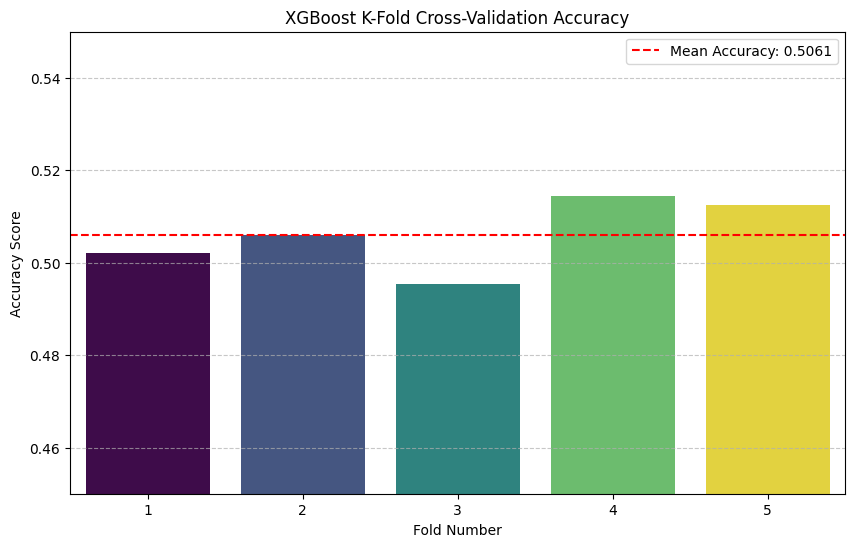

In [160]:

cv_results_df = pd.DataFrame({
    'Fold': range(1, num_folds + 1),
    'Accuracy': cv_scores
})
plt.figure(figsize=(10, 6))
sns.barplot(x='Fold', y='Accuracy', data=cv_results_df, palette='viridis', hue='Fold', legend=False)
plt.axhline(y=np.mean(cv_scores), color='r', linestyle='--', label=f'Mean Accuracy: {np.mean(cv_scores):.4f}')
plt.title('XGBoost K-Fold Cross-Validation Accuracy')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy Score')
plt.ylim(0.45, 0.55) # Adjusted y-axis for better visualization of current scores
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Random Search

In [ ]:
# Paramètres autour du baseline pour RandomizedSearch
param_dist = {
     'n_estimators': randint(100, 200),       # baseline = 100 inclus
    'max_depth': randint(6, 10),             # baseline = 6 inclus
    'learning_rate': uniform(0.01, 0.3),    # baseline = 0.3 inclus
    'subsample': uniform(0.8, 0.2),         # baseline = 1.0 inclus
    'colsample_bytree': uniform(0.8, 0.2)   # baseline = 1.0 inclus

}
# RandomizedSearchCV
xgb_random = RandomizedSearchCV(
    estimator=xgb_baseline,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='accuracy', 
    n_jobs=-1,
    random_state=42,
    verbose=2
)
# --------------------------
# Entraînement
# --------------------------
xgb_random.fit(X_train_scaled, y_train)

# --------------------------
# Meilleur modèle et évaluation
# --------------------------
best_xgb = xgb_random.best_estimator_
y_pred = best_xgb.predict(X_test_scaled)
y_proba = best_xgb.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"\nOptimized XGBoost - Accuracy: {acc:.4f} | Balanced Acc: {bal_acc:.4f} | AUC: {auc:.4f}")
print(f"Best params: {xgb_random.best_params_}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# --------------------------
# Feature importance
# --------------------------
importance = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 5 Important Features:")
for i, (feat, imp) in enumerate(importance.head(5).items(), 1):
    print(f"  {i}. {feat}: {imp:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Optimized XGBoost - Accuracy: 0.5025 | Balanced Acc: 0.5025 | AUC: 0.4974
Best params: {'colsample_bytree': np.float64(0.893352578649596), 'learning_rate': np.float64(0.26798212202089616), 'max_depth': 8, 'n_estimators': 120, 'subsample': np.float64(0.8900998503939086)}

Classification Report:
              precision    recall  f1-score   support

  decreasing       0.50      0.50      0.50      1004
  increasing       0.50      0.51      0.50       996

    accuracy                           0.50      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.50      0.50      0.50      2000


Top 5 Important Features:
  1. Gender_Diversity_%: 0.1001
  2. Automation_Risk_%: 0.0988
  3. Job_Value_Index: 0.0977
  4. Median_Salary_USD: 0.0959
  5. Vulnerability_Index: 0.0924


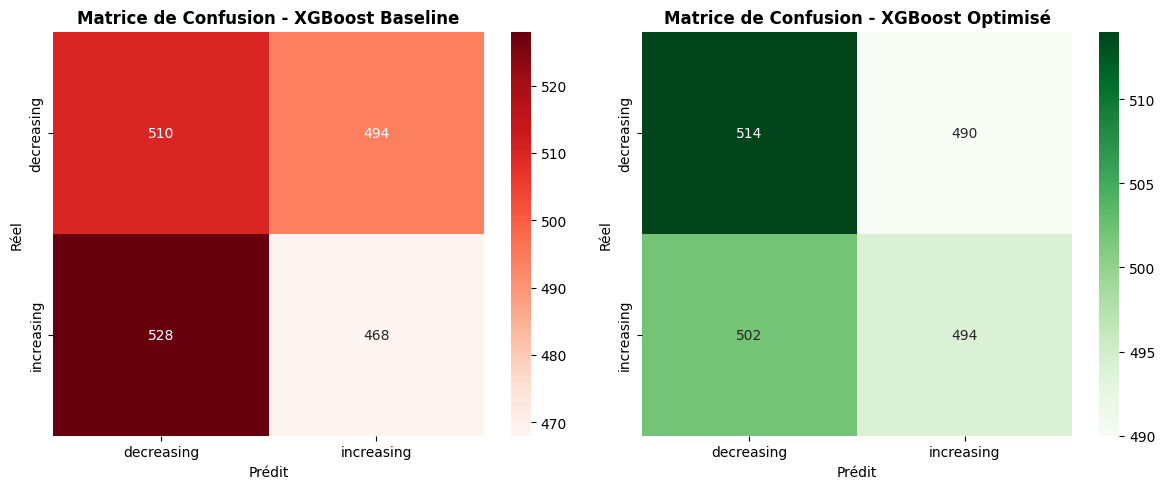

In [165]:
# 3. Matrice de confusion corrigée
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm_xgb_baseline = confusion_matrix(y_test, y_pred_baseline)
sns.heatmap(cm_xgb_baseline, annot=True, fmt='d', cmap='Reds', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de Confusion - XGBoost Baseline', fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')

plt.subplot(1, 2, 2)
cm_xgb_opt = confusion_matrix(y_test, y_pred_fold)
sns.heatmap(cm_xgb_opt, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de Confusion - XGBoost Optimisé', fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')

plt.tight_layout()
plt.show()


# **svm**

In [ ]:
from sklearn.svm import SVC


svm_poly = SVC(kernel='poly', degree=3, random_state=42)  # degree=3 par défaut
svm_poly.fit(X_train_scaled, y_train)
y_pred_poly = svm_poly.predict(X_test_scaled)

print(f"SVM Polynomial - Accuracy: {accuracy_score(y_test, y_pred_poly):.4f}")
print(f"SVM Polynomial - Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_poly):.4f}")
print("\nRapport de classification SVM Polynomial :")
print(classification_report(y_test, y_pred_poly, target_names=class_names))

# SVM avec noyau polynômial
svm_poly = SVC(kernel='poly', degree=3, random_state=42)  # degree=3 par défaut
svm_poly.fit(X_train_scaled, y_train)
y_pred_poly = svm_poly.predict(X_test_scaled)

print(f"SVM Polynomial - Accuracy: {accuracy_score(y_test, y_pred_poly):.4f}")
print(f"SVM Polynomial - Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_poly):.4f}")
print("\nRapport de classification SVM Polynomial :")
print(classification_report(y_test, y_pred_poly, target_names=class_names))

SVM Polynomial - Accuracy: 0.5125
SVM Polynomial - Balanced Accuracy: 0.5124

Rapport de classification SVM Polynomial :
              precision    recall  f1-score   support

  decreasing       0.51      0.55      0.53      1004
  increasing       0.51      0.48      0.49       996

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000

SVM Polynomial - Accuracy: 0.5125
SVM Polynomial - Balanced Accuracy: 0.5124

Rapport de classification SVM Polynomial :
              precision    recall  f1-score   support

  decreasing       0.51      0.55      0.53      1004
  increasing       0.51      0.48      0.49       996

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000



##Compare Search Results

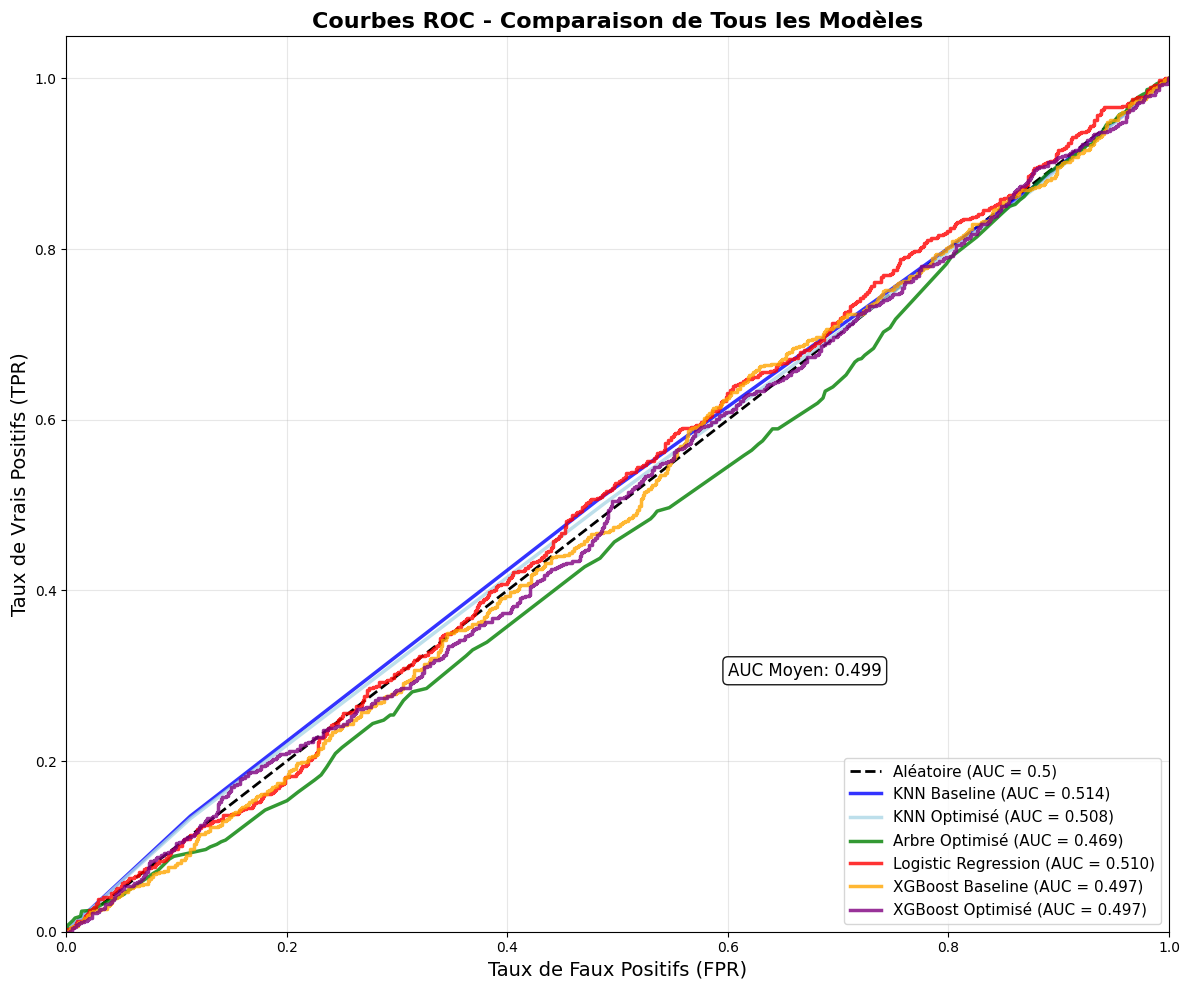


SCORES AUC POUR TOUS LES MODÈLES:
KNN Baseline              AUC = 0.5136
KNN Optimisé              AUC = 0.5084
Arbre Optimisé            AUC = 0.4692
Logistic Regression       AUC = 0.5099
XGBoost Baseline          AUC = 0.4968
XGBoost Optimisé          AUC = 0.4974


In [ ]:
# --------------------------
# ROC & Comparison
# --------------------------

from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities
y_proba_knn = knn_baseline.predict_proba(X_test_scaled)[:, 1]
y_proba_knn_opt = best_knn.predict_proba(X_test_scaled)[:, 1]
y_proba_tree = best_tree.predict_proba(X_test)[:, 1]
y_proba_lr = best_lr.predict_proba(X_test_scaled)[:, 1]
y_proba_xgb = xgb_baseline.predict_proba(X_test)[:, 1]
y_proba_xgb_opt = best_xgb.predict_proba(X_test_scaled)[:, 1]

# Store models and their probabilities
models_roc = {
    'KNN Baseline': y_proba_knn,
    'KNN Optimisé': y_proba_knn_opt,
    'Arbre Optimisé': y_proba_tree,
    'Logistic Regression': y_proba_lr,
    'XGBoost Baseline': y_proba_xgb,
    'XGBoost Optimisé': y_proba_xgb_opt
}

# Plot ROC curves
plt.figure(figsize=(12, 10))
plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.5)', linewidth=2)

colors = ['blue', 'lightblue', 'green', 'red', 'orange', 'purple']
for idx, (name, y_prob) in enumerate(models_roc.items()):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=colors[idx], linewidth=2.5,
             label=f'{name} (AUC = {auc_score:.3f})', alpha=0.8)

plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=14)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=14)
plt.title('Courbes ROC - Comparaison de Tous les Modèles', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1.05])

# Mean AUC annotation
mean_auc = np.mean([roc_auc_score(y_test, y_prob) for y_prob in models_roc.values()])
plt.text(0.6, 0.3, f'AUC Moyen: {mean_auc:.3f}', fontsize=12,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9))

plt.tight_layout()
plt.show()


In [178]:

# Print AUC scores
print("\nSCORES AUC POUR TOUS LES MODÈLES:")
for name, y_prob in models_roc.items():
    print(f"{name:25} AUC = {roc_auc_score(y_test, y_prob):.4f}")

# Accuracy Comparison
accuracy_scores = {
    'KNN Baseline': acc_knn,
    'KNN Optimisé': acc_knn_opt,
    'Arbre Baseline': acc_tree,
    'Arbre Optimisé': acc_best,
    'Logistic Regression Baseline': acc_lr_baseline,
    'Logistic Regression Optimisé': acc_lr,
    'XGBoost Baseline': acc_baseline,
    'XGBoost Optimisé': acc_best 
}


SCORES AUC POUR TOUS LES MODÈLES:
KNN Baseline              AUC = 0.5136
KNN Optimisé              AUC = 0.5084
Arbre Optimisé            AUC = 0.4692
Logistic Regression       AUC = 0.5099
XGBoost Baseline          AUC = 0.4968
XGBoost Optimisé          AUC = 0.4974



Classement des modèles par Accuracy:
Logistic Regression Baseline   0.5140
KNN Optimisé                   0.5125
Arbre Baseline                 0.5120
KNN Baseline                   0.5120
Logistic Regression Optimisé   0.5035
XGBoost Baseline               0.4890
Arbre Optimisé                 0.4850
XGBoost Optimisé               0.4850


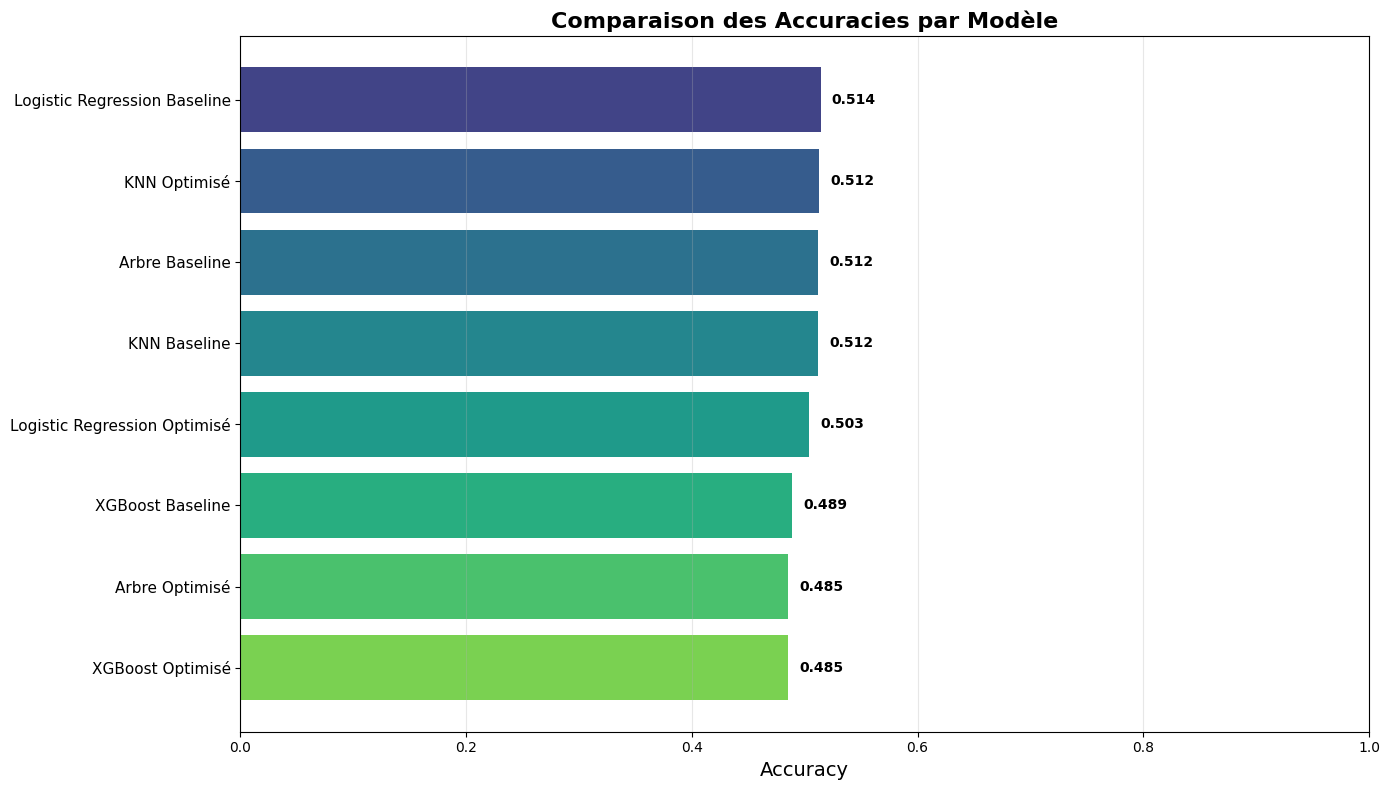

In [179]:
comparison_df = pd.DataFrame(list(accuracy_scores.items()), columns=['Modèle', 'Accuracy'])
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)

print("\nClassement des modèles par Accuracy:")
for idx, row in comparison_df.iterrows():
    print(f"{row['Modèle']:30} {row['Accuracy']:.4f}")

# Visualize
plt.figure(figsize=(14, 8))
bars = plt.barh(range(len(comparison_df)), comparison_df['Accuracy'],
                color=plt.cm.viridis(np.linspace(0.2, 0.8, len(comparison_df))))
plt.yticks(range(len(comparison_df)), comparison_df['Modèle'], fontsize=11)
plt.xlabel('Accuracy', fontsize=14)
plt.title('Comparaison des Accuracies par Modèle', fontsize=16, fontweight='bold')
plt.xlim(0, 1)
for i, (bar, acc) in enumerate(zip(bars, comparison_df['Accuracy'])):
    plt.text(acc + 0.01, i, f'{acc:.3f}', va='center', fontweight='bold', fontsize=10)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [180]:
# --------------------------
# Summary
# --------------------------
best_model_name = comparison_df.iloc[0]['Modèle']
best_accuracy = comparison_df.iloc[0]['Accuracy']
best_auc_model = max(models_roc.items(), key=lambda x: roc_auc_score(y_test, x[1]))[0]
best_auc = roc_auc_score(y_test, models_roc[best_auc_model])

print(f"\n🎯 MEILLEUR MODÈLE: {best_model_name} (Accuracy = {best_accuracy:.4f})")
print(f"📊 MEILLEUR AUC: {best_auc_model} (AUC = {best_auc:.4f})")


🎯 MEILLEUR MODÈLE: Logistic Regression Baseline (Accuracy = 0.5140)
📊 MEILLEUR AUC: KNN Baseline (AUC = 0.5136)
